In [1]:
import matplotlib.pyplot as plt
import scienceplots
from tqdm import tqdm

from e2e.e2esim_uncert import run_e2e_prediction_with_uncertainty
from pathlib import Path

from e2e.e2esim_uncert import plot_outline_with_uncertainty_envelope

import numpy as np
import torch

from e2e.data.resampled import ResampledE2EDataset
from e2e.helpers import timing
from e2e.helpers.wandb import download_model
from e2e.models.mlp import ResMLP
from e2e.models.model import Model
from e2e.models.modelV2 import ModelV2

timing.ENABLE_TIMING = True
from e2e.data.loader import EXPERIMENT as EXP
from e2e.models.recurrent import LSTM
from e2e.prediction.end_to_end import DataLoader, Plotter


plt.style.use(['science', 'ieee', 'grid'])
plt.rcParams.update({"font.size": 12})

%load_ext autoreload
%autoreload 2

2023-11-28 15:41:39,149 - MainThread - INFO - torch.distributed.nn.jit.instantiator - Created a temporary directory at /var/folders/4t/9f3l3jb178g28tncpwrm_fsc0000gn/T/tmp_d0mut2z
2023-11-28 15:41:39,151 - MainThread - INFO - torch.distributed.nn.jit.instantiator - Writing /var/folders/4t/9f3l3jb178g28tncpwrm_fsc0000gn/T/tmp_d0mut2z/_remote_module_non_scriptable.py


In [2]:
MAC_DATA_DIR = Path("/Users/magnus/datasets/WAAM/test")
MLP_INPUT_LENGTH = 224
data_loader = DataLoader(MAC_DATA_DIR)
cross_section_samples = data_loader.load_samples([EXP.RANDOM_EX6])
dataset = ResampledE2EDataset(mirror=False, segment_length=MLP_INPUT_LENGTH).create(cross_section_samples)

100%|██████████| 56/56 [00:06<00:00,  8.81it/s]


In [3]:
# GLOBAL
VERSION = "best"
DEVICE = "cpu"

# MLP
MLP_PROJECT_NAME = "waam-e2e-footprint"
MLP_RUN_ID = "y21szkna"

MLP_INPUT_LENGTH = 224
MLP_HIDDEN_LENGTH_FACTOR = 2
MLP_TARGET_LENGTH = 2
MLP_N_LAYERS = 3
MLP_P = 0.5

# LSTM
LSTM_INPUT_LENGTH = 90
LSTM_TARGET_LENGTH = 90
LSTM_P = 0.9

N_PREDICTIONS = 30

mlp = ResMLP(
    p=MLP_P,
    n_input_features=MLP_INPUT_LENGTH,
    n_hidden=MLP_INPUT_LENGTH * MLP_HIDDEN_LENGTH_FACTOR,
    n_output_features=MLP_TARGET_LENGTH,
    n_layers=MLP_N_LAYERS,
)

lstm = LSTM(
    p=LSTM_P,
    n_input_features=LSTM_INPUT_LENGTH,
    n_output_features=LSTM_TARGET_LENGTH,
    n_hidden=LSTM_TARGET_LENGTH * 3,
    n_layers=10,
)

# instantiate models

footprint_path = download_model(project=MLP_PROJECT_NAME, run_id=MLP_RUN_ID, version=VERSION)

footprint_predictor = Model.load_from_checkpoint(
    model=mlp, checkpoint_path=footprint_path, map_location=torch.device(DEVICE)
)

base = Path("/Users/magnus/repos/waam-e2e/e2e/")
lstm_path = base / Path("./waam-e2e-pre/mbw4tdhh/checkpoints/epoch=199-step=2400.ckpt")
shape_predictor = ModelV2.load_from_checkpoint(
    model=lstm, checkpoint_path=lstm_path, map_location=torch.device(DEVICE)
)
shape_predictor.to("cpu")

wandb:   1 of 1 files downloaded.  
/Users/magnus/miniconda3/envs/waam310/lib/python3.10/site-packages/lightning/pytorch/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.0.3, which is newer than your current Lightning version: v2.0.2
  rank_zero_warn(


ModelV2(
  (model): LSTM(
    (bn1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc): Linear(in_features=90, out_features=90, bias=True)
    (bn2): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (lstm): LSTM(90, 270, num_layers=10, batch_first=True, dropout=0.9)
    (fc2): Linear(in_features=270, out_features=90, bias=True)
    (combine): Linear(in_features=91, out_features=45, bias=True)
    (out): Linear(in_features=45, out_features=3, bias=True)
  )
)

In [21]:
xts = []
zs = []

start_idx = 0
hatch_distance = 52
offset = hatch_distance // 2

L = 10
for l in range(L+1):
    zs.extend(np.array([l]*(L-l)))
    layer = np.arange(start_idx, start_idx + hatch_distance * (L-l), hatch_distance, dtype=int)
    xts.extend(layer)
    start_idx += offset

xts = np.array(xts)
zs = np.array(zs)

2023-11-28 15:53:27,506 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-28 15:53:27,511 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-28 15:53:27,514 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-28 15:53:27,519 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-28 15:53:27,523 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-28 15:53:27,523 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-28 15:53:27,526 - MainThread - INFO - matplotlib.texmanager - No LaT

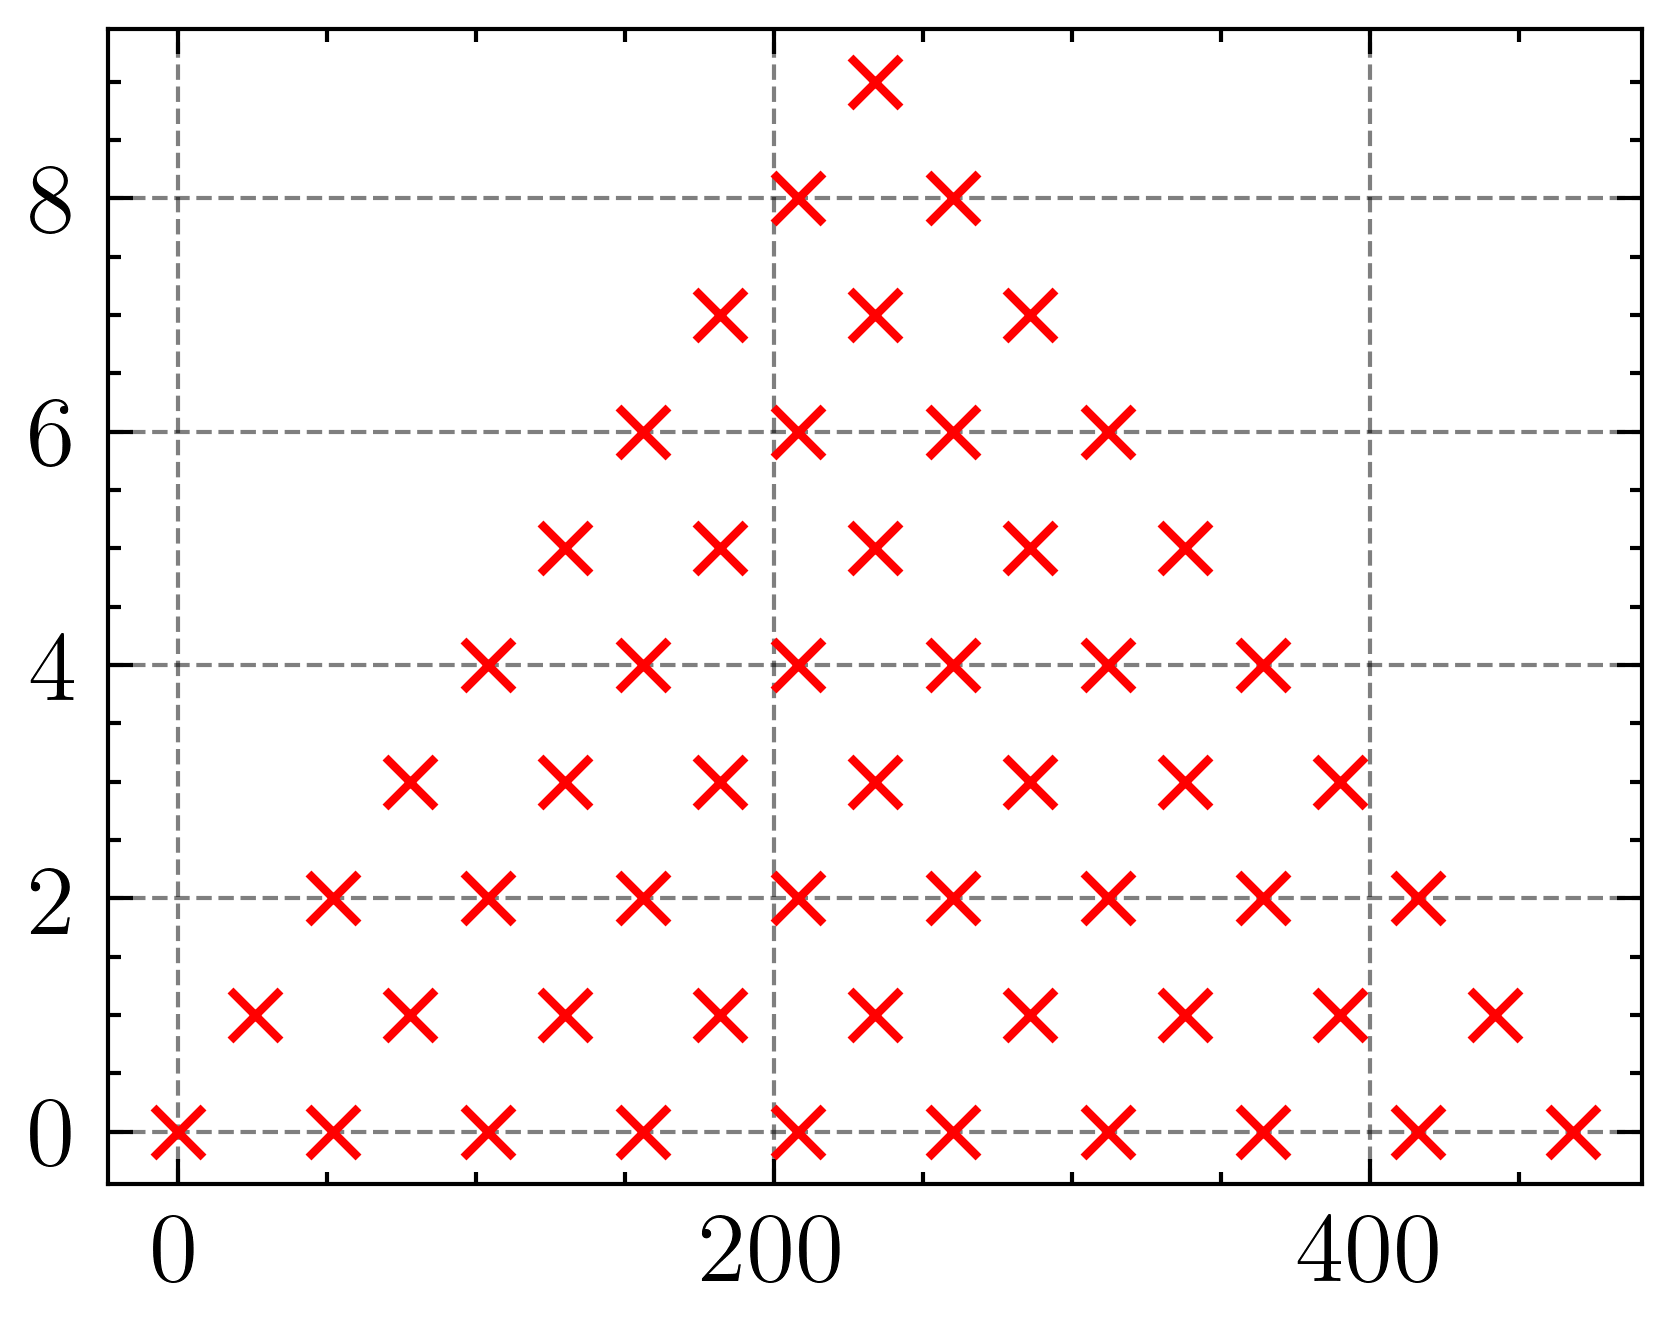

In [22]:
plt.scatter(xts, zs, color="red", marker="x", alpha=1)

In [25]:
SIMUlATION_RUNS = 30

start_idx = 279
hatch_distance = 52
offset = hatch_distance // 2

mean_outlines = []
std_outlines = []

for L in [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]:
    xts = []
    zs = []
    
    for l in range(L+1):
        zs.extend(np.array([l]*(L-l)))
        # noise = np.random.normal(0, 5, size=(L-l))
        # noise to int
        # noise = noise.astype(int)
        layer = np.arange(start_idx, start_idx + hatch_distance * (L-l), hatch_distance, dtype=int)
        # xts.extend(layer+noise)
        xts.extend(layer)
        start_idx += offset
    
    xts = np.array(xts)
    zs = np.array(zs)

    dataset.torchpositions = xts
    
    outlines = []
    for iter in tqdm(range(SIMUlATION_RUNS)):
        try:
            dataset = run_e2e_prediction_with_uncertainty(footprint_predictor, shape_predictor, dataset, N_PREDICTIONS=1)
            outline = np.array(dataset.predictions).max(axis=0)
        except:
            print(f"simulation for L={L} failed")
            # outlines.append(np.zeros(701))
            dataset.predictions = []
            break
            
        dataset.predictions = []
        outlines.append(outline)
    
    outlines = np.array(outlines)
    mean_outline = outlines.mean(axis=0)
    std_outline = outlines.std(axis=0)
    
    mean_outlines.append(mean_outline)
    std_outlines.append(std_outline)


  0%|          | 0/30 [00:00<?, ?it/s]
/var/folders/4t/9f3l3jb178g28tncpwrm_fsc0000gn/T/ipykernel_39631/3312392347.py:44: RuntimeWarning: Mean of empty slice.
  mean_outline = outlines.mean(axis=0)


simulation for L=20 failed


  0%|          | 0/30 [00:00<?, ?it/s]


simulation for L=30 failed


  0%|          | 0/30 [00:00<?, ?it/s]


...

simulation for L=80 failed


  0%|          | 0/30 [00:00<?, ?it/s]


simulation for L=90 failed


  0%|          | 0/30 [00:00<?, ?it/s]

simulation for L=100 failed


In [9]:
for std_outline in std_outlines:
    print(std_outline.mean(), std_outline.max())
    # plt.plot(std_outline)

0.308147 0.6065619
0.3348657 0.7232661
0.32562867 0.70059115
0.34096268 0.6759349
0.3440312 0.7006196
0.31316367 0.6256128
0.31547526 0.6421015
0.31844842 0.62670624
0.3334442 0.6719056
0.34085104 0.6202616


In [24]:
outlines = np.array(outlines)
outlines.shape

(300, 701)

In [25]:
mean_outline = outlines.mean(axis=0)
std_outline = outlines.std(axis=0)

In [15]:
!pwd

/Users/magnus/repos/waam-e2e/e2e


In [26]:
std_outline.mean(), std_outline.max()

(0.33238393, 0.5605019)

In [22]:
std_outline.mean(), std_outline.max()

(0.3176994, 0.5971606)

In [18]:
outputs = Path("./outputs")
sim = outputs / "sim"
# save mean outline
np.save(sim / "mean_outline.npy", mean_outline)
np.save(sim / "std_outline.npy", std_outline)

In [19]:
start = 40
end = 670

In [20]:
ts_zero = []
for gt in dataset.ground_truth:
    t = gt[200:901]
    offset = np.mean(t[:40])
    t = t - offset
    ts_zero.append(t)
    
ts = np.array(ts_zero)
outline_true = ts.max(axis=0)

In [ ]:
fig = plot_outline_with_uncertainty_envelope(mean_outline, std_outline)

2023-11-27 16:32:25,900 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-27 16:32:25,910 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-27 16:32:25,940 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-27 16:32:25,950 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-27 16:32:25,970 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-27 16:32:25,987 - MainThread - INFO - matplotlib.texmanager - No LaTeX-compatible font found for the serif fontfamily in rcParams. Using default.
2023-11-27 16:32:25,999 - MainThread - INFO - matplotlib.texmanager - No LaT

In [ ]:
e2esim = Path("/Users/magnus/Desktop/graphics/results/e2esim")
# fig.savefig(e2esim / "e2esim_uncertainty_envelope.pdf", bbox_inches="tight")